In [1]:
%%writefile pipeline/AAA_test.py
print("HH")
impor numpy as np
print("hello world")

Overwriting pipeline/AAA_test.py


In [92]:
import torch

data = torch.load("dataset/beams/train/graph_00.pt", weights_only=False)
batch = Batch.from_data_list(data)

In [95]:
torch.tensor(batch.cells).squeeze().shape

torch.Size([49, 768, 4])

In [99]:
graph = batch
torch.tensor(graph.volume).squeeze().shape

torch.Size([49, 768])

In [75]:
cells = torch.tensor(batch.x_element_connectivity).reshape(49,768,4).to(torch.long)

In [76]:
x_new.shape

torch.Size([49, 225, 3])

In [77]:
cells.shape

torch.Size([49, 768, 4])

In [78]:
import torch

def batched_tetrahedron_volumes(x: torch.Tensor, cells: torch.Tensor) -> torch.Tensor:
    """
    Calculates the volumes of tetrahedra in a batched manner using the scalar triple product.
    Preserves gradients for 'x'.

    Args:
        x (torch.Tensor): Coordinates of points. Shape (B, N, 3).
        cells (torch.Tensor): Indices of the 4 vertices forming each tetrahedron. Shape (B, M, 4).

    Returns:
        torch.Tensor: Volumes of the tetrahedra. Shape (B, M).
    """
    B, M, _ = cells.shape

    # 1. Advanced Indexing to gather coordinates
    # We create a batch index tensor to pair with the cell indices.
    # batch_idx shape: (B, M, 4)
    batch_idx = torch.arange(B, device=x.device).view(B, 1, 1).expand(B, M, 4)
    
    # Gather the coordinates for every vertex in every cell.
    # Result shape: (B, M, 4, 3)
    tetra_coords = x[batch_idx, cells]

    # 2. Unbind coordinates into 4 distinct vertices (A, B, C, D)
    # Each will have shape (B, M, 3)
    a, b, c, d = tetra_coords.unbind(dim=2)

    # 3. Calculate edges relative to vertex D
    # Shape: (B, M, 3)
    ad = a - d
    bd = b - d
    cd = c - d

    # 4. Compute Scalar Triple Product
    # Cross product of two edges (bd x cd)
    cross_prod = torch.cross(bd, cd, dim=-1)
    
    # Dot product of ad with the result of the cross product
    # We emulate dot product using element-wise mult + sum over the last dimension
    scalar_triple = torch.sum(ad * cross_prod, dim=-1)

    # 5. Volume = 1/6 * |Scalar Triple Product|
    volumes = torch.abs(scalar_triple) / 6.0

    return volumes

batched_tetrahedron_volumes(x_new, cells), all_volumes

(tensor([[5.6574e-06, 5.4312e-06, 5.3732e-06,  ..., 5.9646e-06, 6.2982e-06,
          6.1454e-06],
         [5.6676e-06, 5.4557e-06, 5.3894e-06,  ..., 5.9145e-06, 6.3510e-06,
          6.1931e-06],
         [5.6950e-06, 5.5175e-06, 5.4259e-06,  ..., 5.9722e-06, 6.4976e-06,
          6.2709e-06],
         ...,
         [5.5766e-06, 5.2238e-06, 5.3050e-06,  ..., 5.7837e-06, 5.8421e-06,
          6.1364e-06],
         [5.5090e-06, 5.1429e-06, 5.2585e-06,  ..., 5.3371e-06, 5.6946e-06,
          5.8391e-06],
         [5.4867e-06, 5.1390e-06, 5.2381e-06,  ..., 5.3539e-06, 5.8943e-06,
          5.7700e-06]], grad_fn=<DivBackward0>),
 tensor([5.6251e-06, 5.6250e-06, 5.6251e-06,  ..., 5.6320e-06, 5.6319e-06,
         5.6317e-06]))

ValueError: cells must have shape (B, M, 4). Got (768, 4)

In [80]:
import torch

def tetra_volumes_batched(x: torch.Tensor, cells: torch.Tensor, *, oriented: bool = False) -> torch.Tensor:
    """
    x:     (B, N, 3) float
    cells: (B, M, 4) long indices into N
    returns: (B, M) volumes
    """
    if x.ndim != 3 or x.shape[-1] != 3:
        raise ValueError(f"x must have shape (B, N, 3). Got {tuple(x.shape)}")
    if cells.ndim != 3 or cells.shape[-1] != 4:
        raise ValueError(f"cells must have shape (B, M, 4). Got {tuple(cells.shape)}")
    if cells.dtype != torch.long:
        cells = cells.long()

    B, N, _ = x.shape
    Bb, M, _ = cells.shape
    if Bb != B:
        raise ValueError(f"Batch size mismatch: x has B={B}, cells has B={Bb}")

    # --- gather vertices per tet using batch-offset indexing ---
    # Flatten x to (B*N, 3), and convert (b, idx) -> flat index b*N + idx
    x_flat = x.reshape(B * N, 3)  # (B*N, 3)

    base = (torch.arange(B, device=x.device, dtype=cells.dtype) * N)[:, None, None]  # (B,1,1)
    flat_idx = cells + base  # (B,M,4)

    verts = x_flat[flat_idx]  # (B,M,4,3)

    v0 = verts[:, :, 0, :]
    v1 = verts[:, :, 1, :]
    v2 = verts[:, :, 2, :]
    v3 = verts[:, :, 3, :]

    a = v1 - v0
    b = v2 - v0
    c = v3 - v0

    triple = torch.sum(a * torch.cross(b, c, dim=-1), dim=-1)  # (B,M)
    vol = triple / 6.0
    return vol if oriented else vol.abs()

tetra_volumes_batched(x_new, cells)

tensor([[5.6574e-06, 5.4312e-06, 5.3732e-06,  ..., 5.9646e-06, 6.2982e-06,
         6.1454e-06],
        [5.6676e-06, 5.4557e-06, 5.3894e-06,  ..., 5.9145e-06, 6.3510e-06,
         6.1931e-06],
        [5.6950e-06, 5.5175e-06, 5.4259e-06,  ..., 5.9722e-06, 6.4976e-06,
         6.2709e-06],
        ...,
        [5.5766e-06, 5.2238e-06, 5.3050e-06,  ..., 5.7837e-06, 5.8422e-06,
         6.1364e-06],
        [5.5090e-06, 5.1429e-06, 5.2585e-06,  ..., 5.3371e-06, 5.6946e-06,
         5.8391e-06],
        [5.4867e-06, 5.1390e-06, 5.2381e-06,  ..., 5.3539e-06, 5.8943e-06,
         5.7700e-06]], grad_fn=<AbsBackward0>)

In [3]:
from torch_geometric.data import Batch
import torch
train = torch.load("dataset/beams/train/graph_00.pt", weights_only=False)
batch = Batch.from_data_list(train)
batch

DataBatch(edge_index=[2, 112896], t=[49], y_acc_t=[11025, 3], x_pos_t=[11025, 3], x_vel_t=[11025, 3], volume=[49], next_volume=[49], cells=[49], x=[11025, 13], edge_attr=[112896, 8], y=[11025, 4], batch=[11025], ptr=[50])

In [69]:
from models.vinay_mgn import MeshGraphNet


node_channels = 13
edge_channels = 8
num_messages = 8
latent_dim = 128

torch.manual_seed(42)
model = MeshGraphNet(
    node_channels=node_channels,
    edge_channels=edge_channels,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
pred = model(batch)[:,:3]

In [70]:
from mesh_utils import volume
reshaped_a = pred.reshape(len(batch), -1, 3)
reshaped_x = batch.x_pos_t.reshape(len(batch), -1, 3)
reshaped_v = batch.x_vel_t.reshape(len(batch), -1, 3)
dt = 0.08
v_new = reshaped_v + (reshaped_a * dt)
x_new = reshaped_x + (v_new * dt)
x_new.shape

torch.Size([49, 225, 3])

In [ ]:

def volume(V: torch.Tensor, T: torch.Tensor, abs=True) -> torch.Tensor:
    # Dimension:
    a = V[T[:, 0], :]
    b = V[T[:, 1], :]
    c = V[T[:, 2], :]
    d = V[T[:, 3], :]
    vols = -torch.sum(torch.mul(a - d, torch.cross(b - c, c - d, dim=1)), dim=1) / 6.0
    if abs:
        vols = torch.abs(vols)
    return vols

all_volumes = []
for x, cells in zip(reshaped_x,cells):
    c = torch.tensor(cells, dtype=torch.long)
    V = volume(x,c)
    all_volumes.extend(V)
all_volumes = torch.tensor(all_volumes)
all_volumes.shape

/tmp/ipykernel_7763/1921778893.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c = torch.tensor(cells, dtype=torch.long)


torch.Size([37632])

In [81]:
import torch

def batched_tetrahedron_volumes(x: torch.Tensor, cells: torch.Tensor) -> torch.Tensor:
    """
    Calculates volumes matching the user's specific logic and output format.
    
    Args:
        x: (B, N, 3)
        cells: (B, M, 4)
        
    Returns:
        volumes: (B*M)  <-- Flattened to match your loop's output
    """
    B, M, _ = cells.shape

    # 1. Create Batch Indices for gathering
    # We need to grab specific nodes from specific batches
    # batch_idx: (B, M, 4)
    batch_idx = torch.arange(B, device=x.device).view(B, 1, 1).expand(B, M, 4)
    
    # 2. Gather coordinates
    # x[batch_idx, cells] allows us to pick node 'cells[b,m,k]' from batch 'b'
    # Result: (B, M, 4, 3)
    tetra_coords = x[batch_idx, cells]

    # 3. Unbind into vertices (A, B, C, D)
    # Each shape: (B, M, 3)
    a, b, c, d = tetra_coords.unbind(dim=2)

    # 4. Compute vectors exactly as in your loop
    # Your logic: cross(b-c, c-d) dot (a-d)
    vec_a_d = a - d
    vec_b_c = b - c
    vec_c_d = c - d

    # 5. Cross Product (b-c) x (c-d)
    # dim=-1 ensures we cross along the coordinate dimension (x,y,z)
    cross_prod = torch.cross(vec_b_c, vec_c_d, dim=-1)

    # 6. Dot Product (manual)
    # sum(vec_a_d * cross, dim=-1)
    scalar_triple = torch.sum(vec_a_d * cross_prod, dim=-1)

    # 7. Volume and Flatten
    volumes = torch.abs(scalar_triple) / 6.0
    
    # Flatten to (B*M) to match your 'all_volumes' list structure
    return volumes.flatten() 

# --- Verification Script ---
if __name__ == "__main__":
    # Mock Data
    B, N, M = 2, 10, 5
    x = torch.randn(B, N, 3)
    cells = torch.randint(0, N, (B, M, 4))

    # 1. Your Loop Method
    def volume_single(V, T):
        a = V[T[:, 0], :]
        b = V[T[:, 1], :]
        c = V[T[:, 2], :]
        d = V[T[:, 3], :]
        vols = -torch.sum(torch.mul(a - d, torch.cross(b - c, c - d, dim=1)), dim=1) / 6.0
        return torch.abs(vols)

    all_volumes = []
    for i in range(B):
        # Simulating your zip(reshaped_x, cells)
        v = volume_single(x[i], cells[i])
        all_volumes.extend(v)
    all_volumes = torch.stack(all_volumes) # Stack is better than tensor(list)

    # 2. Batched Method
    batched_vols = batched_tetrahedron_volumes(x, cells)

    # 3. Compare
    print(f"Loop shape:    {all_volumes.shape}")
    print(f"Batched shape: {batched_vols.shape}")
    
    # Check closeness
    diff = torch.abs(all_volumes - batched_vols).max()
    print(f"Max difference: {diff.item():.9f}")
    assert torch.allclose(all_volumes, batched_vols, atol=1e-6)
    print("Success: Outputs match!")

Loop shape:    torch.Size([10])
Batched shape: torch.Size([10])
Max difference: 0.000000000
Success: Outputs match!


In [12]:
from gpytoolbox import volume

In [13]:
true_V = 0.12 * 0.9 * 0.04
print("True volume:", true_V)

True volume: 0.00432


In [14]:
import numpy as np

v = np.array(
    [[0.0, 0.0, 0.0], [1.0, 0.0, 0.0], [0.0, 1.0, 0.0], [0.0, 0.0, 1.0], [2, 2, 1000]]
)
# This tet is properly oriented
t = np.array([[0, 1, 2, 3], [0, 1, 2, 3], [0, 1, 2, 4]])
vols = volume(v, t)
print(vols)
# This volume should be 1/6

[  0.16666667   0.16666667 166.66666667]


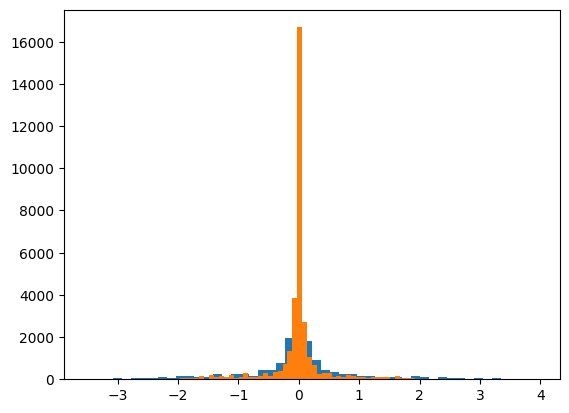

In [15]:
def asinh(x):
    return np.log(x + np.sqrt(x**2 + 1))


import matplotlib.pyplot as plt
from torch_geometric.data import Batch

a = Batch.from_data_list(data).y_acc_t
reduced_a = a[np.isclose(a, 0, atol=0.1) == False]
_ = plt.hist(reduced_a.flatten(), bins=50)
_ = plt.hist(asinh(a.flatten()), bins=50)


In [16]:
(reduced_a).mean(), a.mean()

(tensor(-0.0245), tensor(-0.0075))

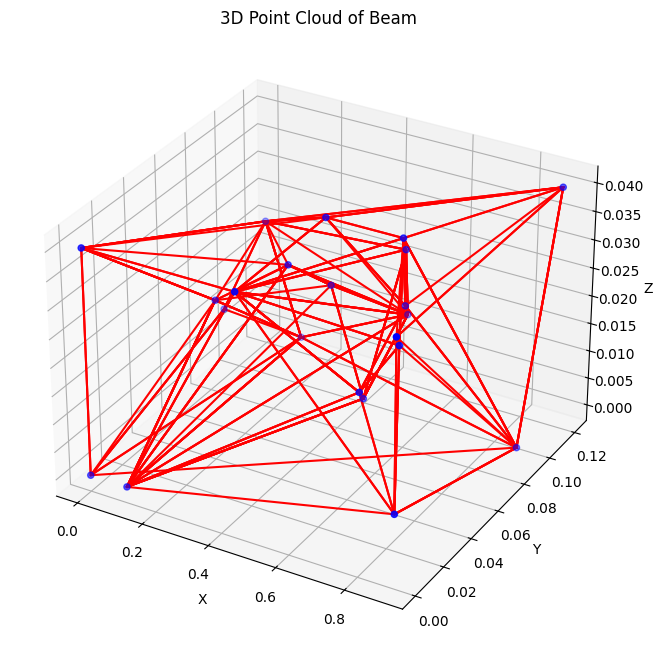

In [18]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt


x = data[0].x_pos_t.numpy()
n = x.shape[0] // 10

indices = np.random.choice(x.shape[0], size=n, replace=False)
x = x[indices]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x[:, 0], x[:, 1], x[:, 2], c="b", marker="o", s=20)

tri = Delaunay(x)
for simplex in tri.simplices:
    ax.plot(x[simplex, 0], x[simplex, 1], x[simplex, 2], "r-")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D Point Cloud of Beam")
plt.show()

Total volume: 0.0043200054
Total volume: 0.0043201162
Total volume: 0.004320808
Total volume: 0.004323219
Total volume: 0.0043288893
Total volume: 0.0043384642
Total volume: 0.0043509863
Total volume: 0.0043642176
Total volume: 0.004375387
Total volume: 0.0043829405
Total volume: 0.0043748696
Total volume: 0.0043475498
Total volume: 0.004324124
Total volume: 0.004323066
Total volume: 0.004345578
Total volume: 0.0043643517
Total volume: 0.0043596905
Total volume: 0.0043385117
Total volume: 0.0043212455
Total volume: 0.0043256963
Total volume: 0.004344083
Total volume: 0.004355724
Total volume: 0.0043482725
Total volume: 0.0043296516
Total volume: 0.0043200552
Total volume: 0.004328102
Total volume: 0.004343904
Total volume: 0.0043499656
Total volume: 0.004340032
Total volume: 0.004325131
Total volume: 0.004320249
Total volume: 0.004329101
Total volume: 0.004340807
Total volume: 0.0043424265
Total volume: 0.00433259
Total volume: 0.0043219225
Total volume: 0.0043213256
Total volume: 0.00

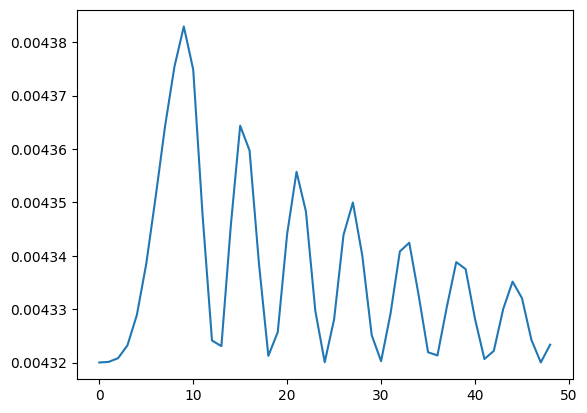

In [19]:
volumes_list = []
for i in range(len(data)):
    pos = data[i].x_pos_t.numpy()
    cells = data[i].x_element_connectivity[0]
    # print("Number of nodes:", pos.shape)
    # print("Number of elements:", cells.shape)
    volumes = volume(pos, cells)
    # volumes are signed
    V = np.abs(volumes).sum()
    print("Total volume:", V)
    volumes_list.append(V)
plt.plot(volumes_list)

In [100]:
import argparse
from pathlib import Path

import torch

from models.vinay_mgn import MeshGraphNet
from preprocess_data import Stats
from rollout_utils import do_rollout

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

checkpoint_path = Path(
    "saved_models/2026-01-22_10-30-57/Epoch_223_GenLoss_0.0105644353.pth"
)

node_channels = 13
edge_channels = 8
num_messages = 8
latent_dim = 128

dt = 0.08

torch.manual_seed(42)
model = MeshGraphNet(
    node_channels=node_channels,
    edge_channels=edge_channels,
    latent_size=latent_dim,
    num_msgs=num_messages,
)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.to(device)
model.eval()

no_rollout = False


###
import json

from torch_geometric.loader import DataLoader

from in_memory_dataset import InMemoryTimeStepDataset

test_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/val")
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=False)
with open("Results/train/stats/stats.json", "r") as f:
    stats = json.load(f)
node_stats = Stats.from_dict(stats["node"])
edge_stats = Stats.from_dict(stats["edge"])
target_stats = Stats.from_dict(stats["target"])

true_rollout, pred_rollout = do_rollout(
    model=model,
    test_loader=test_dataloader,
    device=device,
    node_stats=node_stats,
    edge_stats=edge_stats,
    target_stats=target_stats,
    dt=dt,
    skip_first=0,
    rollout_steps=99,
    dont_rollout=no_rollout,
)

Found 1 sample files
Loaded the dataset with 49 samples


In [ ]:
def plot_volume_change(pred_rollout, true_rollout, path):
    for pred, true in zip(pred_rollout, true_rollout):
        x_true = true.x_pos_t.numpy()
        x_pred = pred.x_pos_t.numpy()
        cells = np.array(true.x_element_connectivity[0][0])
        print(x_true.shape, x_pred.shape, cells.shape)
        true_volumes = volume(x_true, cells)
        pred_volumes = volume(x_pred, cells)

        V_true = np.abs(true_volumes).sum()
        V_pred = np.abs(pred_volumes).sum()

        true_volumes_list.append(V_true)
        pred_volumes_list.append(V_pred)
        ax.plot(true_volumes_list, label="True Volumes")
    ax.plot(pred_volumes_list, label="Predicted Volumes")
    plt.xlabel("Time Step")
    plt.ylabel("Volume")
    ax.legend()
    plt.savefig(path)

(225, 3) (225, 3) (768, 4)


TypeError: cross(): argument 'input' (position 1) must be Tensor, not numpy.ndarray

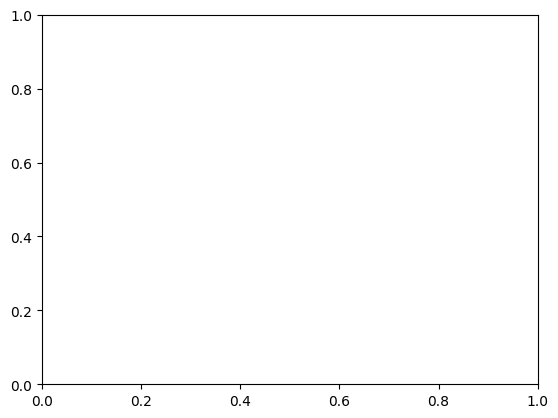

In [102]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use("inline")
fig, ax = plt.subplots()
true_volumes_list = []
pred_volumes_list = []
for pred, true in zip(pred_rollout, true_rollout):
    x_true = true.x_pos_t.numpy()
    x_pred = pred.x_pos_t.numpy()
    cells = np.array(true.x_element_connectivity[0][0])
    print(x_true.shape, x_pred.shape, cells.shape)
    true_volumes = volume(x_true, cells)
    pred_volumes = volume(x_pred, cells)

    V_true = np.abs(true_volumes).sum()
    V_pred = np.abs(pred_volumes).sum()

    true_volumes_list.append(V_true)
    pred_volumes_list.append(V_pred)
ax.plot(true_volumes_list, label="True Volumes")
ax.plot(pred_volumes_list, label="Predicted Volumes")
plt.xlabel("Time Step")
plt.ylabel("Volume")
ax.legend()
plt.show()

In [46]:
from make_gif import make_beam_comparison_gif

In [47]:
%%time
make_beam_comparison_gif(
    pred_rollout=pred_rollout,
    true_rollout=true_rollout,
    L=1.0,
    W=0.1,
    D=0.04,  # Beam dimensions
    out_gif=f"beam_comparison_999.gif",
    fps=4,
)

Rendering frame 0/48
Rendering frame 1/48
Rendering frame 2/48
Rendering frame 3/48
Rendering frame 4/48
Rendering frame 5/48
Rendering frame 6/48
Rendering frame 7/48
Rendering frame 8/48
Rendering frame 9/48
Rendering frame 10/48
Rendering frame 11/48
Rendering frame 12/48
Rendering frame 13/48
Rendering frame 14/48
Rendering frame 15/48
Rendering frame 16/48
Rendering frame 17/48
Rendering frame 18/48
Rendering frame 19/48
Rendering frame 20/48
Rendering frame 21/48
Rendering frame 22/48
Rendering frame 23/48
Rendering frame 24/48
Rendering frame 25/48
Rendering frame 26/48
Rendering frame 27/48
Rendering frame 28/48
Rendering frame 29/48
Rendering frame 30/48
Rendering frame 31/48
Rendering frame 32/48
Rendering frame 33/48
Rendering frame 34/48
Rendering frame 35/48
Rendering frame 36/48
Rendering frame 37/48
Rendering frame 38/48
Rendering frame 39/48
Rendering frame 40/48
Rendering frame 41/48
Rendering frame 42/48
Rendering frame 43/48
Rendering frame 44/48
Rendering frame 45/4

In [ ]:
# one data graph represents a cantilever beam and has
# Data(x=[225, 13],
# edge_index=[2, 2304],
# edge_attr=[2304, 8],
# t=[1],
# x_pos_t=[225, 3],
#  x_vel_t=[225, 3],
# node_force=[225, 3],
# node_force_next=[225, 3],
# x_next=[225, 3],
# v_next=[225, 3],
# y_acc_t=[225, 3],
# y_von_mises=[225, 1],
# x_element_connectivity=[1],
# u=[225, 3])
from torch_geometric.data import Data


def beam_volume(data: Data) -> float:
    """Calculates volume of the beam represented by the data graph.
    Beam can be deformed so use element connectivity to calculate volume of all
    cells and sum them up."""
    volume = 0.0
    # for simplicity assume each element is a rectangular prism
    # with cross-sectional area of 1.0 and length given by distance between nodes
    element_connectivity = data.x_element_connectivity
    for elem in element_connectivity:
        node_indices = elem.tolist()
        node_positions = data.x_pos_t[node_indices]
        # calculate length of element as distance between first and last node
        length = torch.norm(node_positions[-1] - node_positions[0]).item()
        cross_sectional_area = 1.0  # assume unit area
        volume += cross_sectional_area * length
    return volume

In [ ]:
from dolfin import *
import numpy as np
import matplotlib.pyplot as plt
from fenics import project
import torch
from torch_geometric.data import Data, Batch
from torch_geometric.loader import DataLoader
import os
import argparse
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import imageio
from beam_fea_solver import compute_von_mises_3d
from pathlib import Path
from dataclasses import dataclass, asdict

ModuleNotFoundError: No module named 'dolfin'

In [ ]:
import time

time.strftime("%Y-%m-%d_%H-%M-%S")

'2026-01-21_13-13-36'

In [ ]:
@dataclass
class Stats:
    mean: torch.Tensor
    std: torch.Tensor

In [ ]:
dt = 0.08

In [ ]:
from pathlib import Path

data_dir = Path("Results/train/graphs")
filenames = list(data_dir.glob("*.pt"))

train_graphs = []
categorical_node_features = []
valued_node_features = []
edge_features = []
targets = []
for idx, filename in enumerate(filenames):
    dataloader = torch.load(filename, weights_only=False)
    for data in dataloader:
        graph = data.to("cpu")
        graphs.append(graph)
    for graph in graphs:
        boundary_condition = graph.x_bc  # 1 fixed, 0 free
        node_force = graph.x_node_force  # external force on node
        x = graph.x

        categorical_node_features.append(boundary_condition)
        valued_node_features.append(torch.concat([x, graph.x_vel_t, node_force], dim=1))
        train_graphs.append(Data(edge_index=graph.edge_index))

        src, dst = graph.edge_index
        xij = x[dst] - x[src]
        xij_norm = torch.norm(xij, dim=1).unsqueeze(1)
        edge_features.append(torch.concat([xij, xij_norm], dim=1))

        von_mises = compute_von_mises_3d(graph.y_sig_t).unsqueeze(1)
        targets.append(torch.concat([graph.y_acc_t, von_mises], dim=1))


def compute_stats(tensor_list) -> Stats:
    # would also be an option to batch over all tensors
    # Batch.from_data_list(train_graphs).x.mean(dim=0)
    # but this uses less memory

    sum = 0
    sum_sq = 0
    count = 0
    for tensor in tensor_list:
        sum += tensor.sum(dim=0)
        sum_sq += (tensor**2).sum(dim=0)
        count += tensor.shape[0]
    mean = sum / count
    var = (sum_sq / count) - (mean**2)
    std = torch.sqrt(var)
    return Stats(mean=mean, std=std)


def normalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    return (tensor - stats.mean) / (stats.std + eps)


def denormalize(tensor: torch.Tensor, stats: Stats, eps: float = 1e-8) -> torch.Tensor:
    return tensor * (stats.std + eps) + stats.mean


node_stats = compute_stats(valued_node_features)
edge_stats = compute_stats(edge_features)
target_stats = compute_stats(targets)

stats = {
    "node": asdict(node_stats),
    "edge": asdict(edge_stats),
    "target": asdict(target_stats),
}
print(stats)

for i in range(len(train_graphs)):
    _valued_node_features = normalize(valued_node_features[i], node_stats)
    _edge_features = normalize(edge_features[i], edge_stats)
    _targets = normalize(targets[i], target_stats)
    train_graphs[i].x = torch.concat(
        [categorical_node_features[i], _valued_node_features], dim=1
    )
    train_graphs[i].edge_attr = _edge_features
    train_graphs[i].y = _targets

{'node': {'mean': tensor([ 5.6398e-01,  6.2386e-02,  2.7890e-02,  1.6197e-05,  2.6936e-02,
        -4.5063e-04,  0.0000e+00,  1.1443e-02,  0.0000e+00]), 'std': tensor([0.4983, 0.1251, 0.0296, 0.0341, 0.4679, 0.0443, 0.0000, 0.1116, 0.0000])}, 'edge': {'mean': tensor([ 1.8892e-11, -1.6603e-11,  1.5711e-11,  7.2351e-02]), 'std': tensor([0.1439, 0.0254, 0.0123, 0.1275])}, 'target': {'mean': tensor([-6.9054e-06,  1.8023e-03, -5.2576e-03,  8.4858e+00]), 'std': tensor([ 0.1788,  2.0332,  0.1718, 12.3043])}}


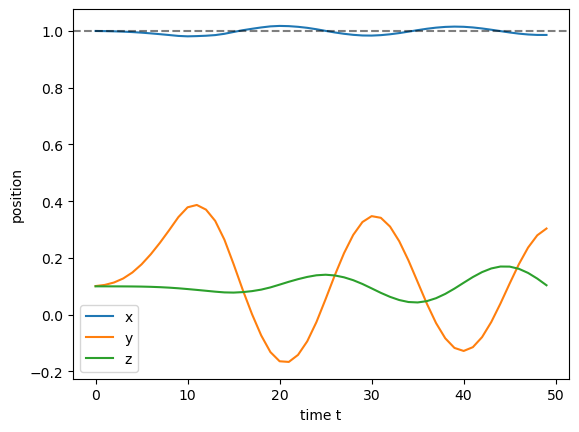

In [ ]:
traj = []
for graph in graphs:
    traj.append(graph.x[-1])
traj = torch.stack(traj).numpy()
plt.plot(traj[:, 0], label="x")
plt.plot(traj[:, 1], label="y")
plt.plot(traj[:, 2], label="z")
plt.axhline(1, color="k", alpha=0.5, linestyle="--")
plt.legend()
plt.xlabel("time t")
plt.ylabel("position")
plt.show()


In [ ]:
default_params = {
    "L": 1.0,
    "W": 0.1,
    "D": 0.1,
    "NL": 4,
    "NW": 2,
    "ND": 2,
    "E": 1000.0,
    "nu": 0.3,
    "rho": 1.0,
    "eta_m": 0.01,
    "eta_k": 0.01,
    "alpha_m": 0.0,
    "alpha_f": 0.0,
    "total_time": 4.0,
    "cutoff_time_factor": 0.2,
    "num_steps": 50,
}

forces = [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
cutoff_time_factors = [0.1, 0.2, 0.3]
lengths = [0.5, 0.75, 1.0]
widths = [0.05, 0.1]
depths = [0.05, 0.1]
from itertools import product

param_combinations = list(product(forces, lengths, widths))
for idx, (initial_force, L, W) in enumerate(param_combinations):
    print(f"\n=== Simulation Set {idx + 1} ===")
    params = default_params.copy()
    params.update(
        {
            "initial_force": initial_force,
            "L": L,
            "W": W,
            "mode": "train",
        }
    )
    print((initial_force, L, W))



=== Simulation Set 1 ===
(0.25, 0.5, 0.05)

=== Simulation Set 2 ===
(0.25, 0.5, 0.1)

=== Simulation Set 3 ===
(0.25, 0.75, 0.05)

=== Simulation Set 4 ===
(0.25, 0.75, 0.1)

=== Simulation Set 5 ===
(0.25, 1.0, 0.05)

=== Simulation Set 6 ===
(0.25, 1.0, 0.1)

=== Simulation Set 7 ===
(0.5, 0.5, 0.05)

=== Simulation Set 8 ===
(0.5, 0.5, 0.1)

=== Simulation Set 9 ===
(0.5, 0.75, 0.05)

=== Simulation Set 10 ===
(0.5, 0.75, 0.1)

=== Simulation Set 11 ===
(0.5, 1.0, 0.05)

=== Simulation Set 12 ===
(0.5, 1.0, 0.1)

=== Simulation Set 13 ===
(0.75, 0.5, 0.05)

=== Simulation Set 14 ===
(0.75, 0.5, 0.1)

=== Simulation Set 15 ===
(0.75, 0.75, 0.05)

=== Simulation Set 16 ===
(0.75, 0.75, 0.1)

=== Simulation Set 17 ===
(0.75, 1.0, 0.05)

=== Simulation Set 18 ===
(0.75, 1.0, 0.1)

=== Simulation Set 19 ===
(1.0, 0.5, 0.05)

=== Simulation Set 20 ===
(1.0, 0.5, 0.1)

=== Simulation Set 21 ===
(1.0, 0.75, 0.05)

=== Simulation Set 22 ===
(1.0, 0.75, 0.1)

=== Simulation Set 23 ===
(1.0,

In [ ]:
import torch

data = torch.load("dataset/beam/val/graph_00.pt", weights_only=False)

In [ ]:
d0 = data[0]
d1 = data[1]

In [ ]:
d0

Data(x=[225, 10], edge_index=[2, 2304], edge_attr=[2304, 4], t=[1], x_pos_t=[225, 3], x_vel_t=[225, 3], node_force=[225, 3], node_force_next=[225, 3], x_next=[225, 3], v_next=[225, 3], y_acc_t=[225, 3], y_von_mises=[225, 1], x_element_connectivity=[1])

In [ ]:
x, v, a = d0.x_pos_t, d0.x_vel_t, d0.y_acc_t
x_next, v_next = d1.x_pos_t, d1.x_vel_t
dt = 0.08

In [ ]:
v_new = v + a * dt
x_new = x + (v + v_new) * dt * 0.5
print(x_new[:6], v_next[:6])
print(x_next[:6], v_next[:6])


tensor([[ 1.4717e-21, -5.9780e-22,  1.5283e-22],
        [ 1.1252e-01, -8.7038e-06,  2.0739e-06],
        [ 2.2507e-01,  4.6647e-05,  4.8729e-06],
        [ 3.3764e-01,  2.1779e-04,  7.7233e-06],
        [ 4.5024e-01,  5.5538e-04,  9.5354e-06],
        [ 5.6286e-01,  1.1046e-03,  9.0426e-06]]) tensor([[7.7881e-20, 6.6629e-20, 3.6090e-21],
        [1.0520e-03, 9.4517e-04, 4.8638e-05],
        [2.2001e-03, 3.9196e-03, 7.3902e-05],
        [3.3874e-03, 9.1499e-03, 8.8115e-05],
        [4.5398e-03, 1.6665e-02, 7.9574e-05],
        [5.5631e-03, 2.6327e-02, 3.9870e-05]])
tensor([[3.7039e-21, 2.4261e-21, 2.0549e-22],
        [1.1255e-01, 3.4325e-05, 2.7751e-06],
        [2.2511e-01, 1.7544e-04, 4.9052e-06],
        [3.3769e-01, 4.5311e-04, 6.6139e-06],
        [4.5028e-01, 8.8874e-04, 6.9971e-06],
        [5.6286e-01, 1.4949e-03, 5.2118e-06]]) tensor([[7.7881e-20, 6.6629e-20, 3.6090e-21],
        [1.0520e-03, 9.4517e-04, 4.8638e-05],
        [2.2001e-03, 3.9196e-03, 7.3902e-05],
        [3.38

In [ ]:
from torch_geometric.data import Data, Batch
import matplotlib.pyplot as plt

b = Batch.from_data_list(data)
plt.hist(b.y_acc_t.flatten(), bins=50)

NameError: name 'data' is not defined

In [ ]:
import torch
from torch import Tensor


def calculate_kinematics(x: Tensor, dt: float) -> tuple[Tensor, Tensor]:
    v0 = torch.zeros(1, x.shape[1], device=x.device, dtype=x.dtype)

    dx = x[1:] - x[:-1]
    v_steps = dx / dt

    v = torch.cat([v0, v_steps], dim=0)

    dv = v[1:] - v[:-1]
    a = dv / dt

    return v, a

In [ ]:
# Create a dummy trajectory: A particle accelerating from 0,0,0
T, dt = 10, 0.1
# Example: x = 0.5 * a * t^2 (Constant acceleration of 4.0)
t = torch.linspace(0, (T - 1) * dt, T).unsqueeze(1)
true_accel = torch.linspace(0.1, 2.7, T)
true_v0 = torch.ones(1, 1) * 2.0

x_traj = true_v0 * t + 0.5 * true_accel.unsqueeze(1) * t**2
x_traj = torch.cat([x_traj, torch.zeros(T, 2)], dim=1)  # Make it 3D (x movement only)

x_true = x_traj
v_true = torch.cat([true_v0 + true_accel.unsqueeze(1) * t, torch.zeros(T, 2)], dim=1)
a_true = true_accel.unsqueeze(1).repeat(1, 3)

In [ ]:
x_true, v_true, a_true

(tensor([[0.0000, 0.0000, 0.0000],
         [0.2019, 0.0000, 0.0000],
         [0.4136, 0.0000, 0.0000],
         [0.6435, 0.0000, 0.0000],
         [0.9004, 0.0000, 0.0000],
         [1.1931, 0.0000, 0.0000],
         [1.5300, 0.0000, 0.0000],
         [1.9199, 0.0000, 0.0000],
         [2.3716, 0.0000, 0.0000],
         [2.8935, 0.0000, 0.0000]]),
 tensor([[2.0000, 0.0000, 0.0000],
         [2.0389, 0.0000, 0.0000],
         [2.1356, 0.0000, 0.0000],
         [2.2900, 0.0000, 0.0000],
         [2.5022, 0.0000, 0.0000],
         [2.7722, 0.0000, 0.0000],
         [3.1000, 0.0000, 0.0000],
         [3.4856, 0.0000, 0.0000],
         [3.9289, 0.0000, 0.0000],
         [4.4300, 0.0000, 0.0000]]),
 tensor([[0.1000, 0.1000, 0.1000],
         [0.3889, 0.3889, 0.3889],
         [0.6778, 0.6778, 0.6778],
         [0.9667, 0.9667, 0.9667],
         [1.2556, 1.2556, 1.2556],
         [1.5444, 1.5444, 1.5444],
         [1.8333, 1.8333, 1.8333],
         [2.1222, 2.1222, 2.1222],
         [2.4111

In [ ]:
v_calc, a_calc, x_recon

(tensor([[0.0000, 0.0000, 0.0000],
         [2.0194, 0.0000, 0.0000],
         [2.1161, 0.0000, 0.0000],
         [2.2994, 0.0000, 0.0000],
         [2.5694, 0.0000, 0.0000],
         [2.9261, 0.0000, 0.0000],
         [3.3694, 0.0000, 0.0000],
         [3.8994, 0.0000, 0.0000],
         [4.5161, 0.0000, 0.0000],
         [5.2194, 0.0000, 0.0000]]),
 tensor([[20.1944,  0.0000,  0.0000],
         [ 0.9667,  0.0000,  0.0000],
         [ 1.8333,  0.0000,  0.0000],
         [ 2.7000,  0.0000,  0.0000],
         [ 3.5667,  0.0000,  0.0000],
         [ 4.4333,  0.0000,  0.0000],
         [ 5.3000,  0.0000,  0.0000],
         [ 6.1667,  0.0000,  0.0000],
         [ 7.0334,  0.0000,  0.0000]]),
 tensor([[0.0000, 0.0000, 0.0000],
         [0.2019, 0.0000, 0.0000],
         [0.4136, 0.0000, 0.0000],
         [0.6435, 0.0000, 0.0000],
         [0.9004, 0.0000, 0.0000],
         [1.1931, 0.0000, 0.0000],
         [1.5300, 0.0000, 0.0000],
         [1.9199, 0.0000, 0.0000],
         [2.3716, 0.0000

In [ ]:
# Calculate
v_calc, a_calc = calculate_kinematics(x_traj, dt)

print(f"Shape of x: {x_traj.shape}")  # (10, 3)
print(f"Shape of v: {v_calc.shape}")  # (10, 3)
print(f"Shape of a: {a_calc.shape}")  # (9, 3)

print(f"\nCalculated a[0] (should be close to {true_accel}):\n{a_calc[0]}")

# --- Verification Rollout ---
# Reconstruct x using the calculated a and v[0]
x_recon = torch.zeros_like(x_traj)
v_recon = torch.zeros_like(v_calc)

x_recon[0] = x_traj[0]
v_recon[0] = v_calc[0]  # 0

for i in range(len(a_calc)):
    # Semi-Implicit Euler
    v_recon[i + 1] = v_recon[i] + a_calc[i] * dt
    x_recon[i + 1] = x_recon[i] + v_recon[i + 1] * dt

error = torch.mean((x_traj - x_recon) ** 2)
print(f"\nReconstruction MSE Loss: {error.item():.6f}")

Shape of x: torch.Size([10, 3])
Shape of v: torch.Size([10, 3])
Shape of a: torch.Size([9, 3])

Calculated a[0] (should be close to tensor([0.1000, 0.3889, 0.6778, 0.9667, 1.2556, 1.5444, 1.8333, 2.1222, 2.4111,
        2.7000])):
tensor([20.1944,  0.0000,  0.0000])

Reconstruction MSE Loss: 0.000000


In [ ]:
from in_memory_dataset import InMemoryTimeStepDataset
from torch_geometric.loader import DataLoader

train_dataset = InMemoryTimeStepDataset(sample_dir="dataset/beam/val")
train_loader = DataLoader(train_dataset, batch_size=9999, shuffle=True)
for item in train_loader:
    data = item

Found 1 sample files
Loaded the dataset with 49 samples


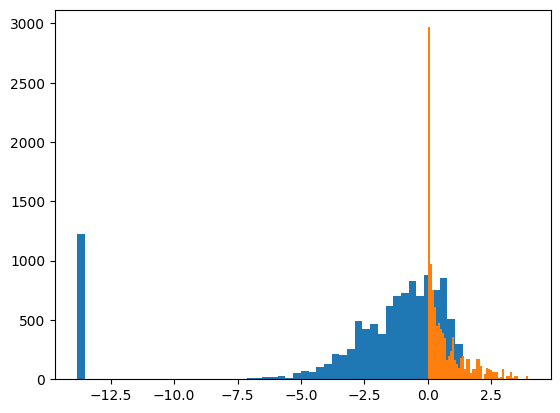

In [ ]:
a = data.y_acc_t.numpy()
anorms = np.linalg.norm(a, axis=1)
_ = plt.hist(np.log(anorms + 1e-6), bins=50)

_ = plt.hist(anorms, bins=50)

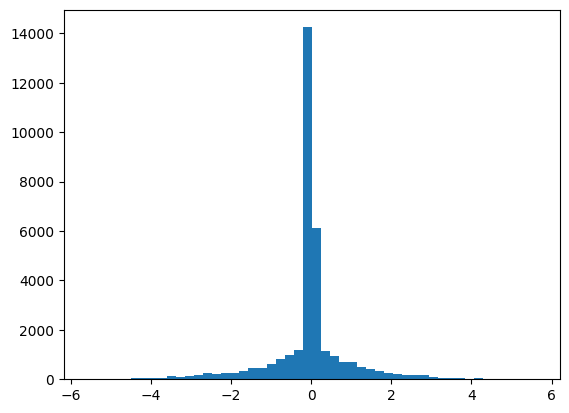

In [ ]:
a_unit = a / (np.linalg.norm(a, axis=1, keepdims=True) + 1e-8)
a_new = a_unit * np.log(anorms + 1e-6).reshape(-1, 1)
_ = plt.hist(a_new.flatten(), bins=50)

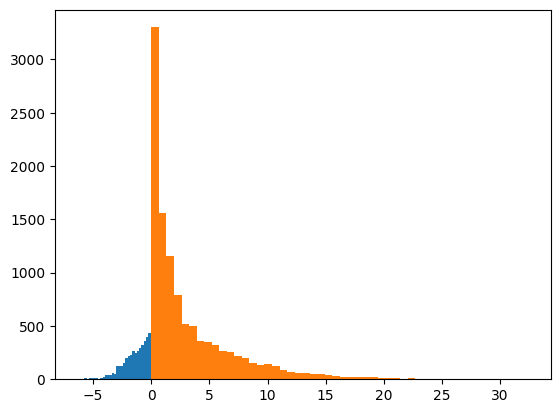

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

vm = data.y_von_mises.flatten()
_ = plt.hist(vm.numpy(), bins=50)
_ = plt.hist(np.exp(vm.numpy() + 1e-6), bins=50)